#**Amerihome Data Project**

In [28]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm

In [29]:
#Load data and skip row 1 to avoid the unnessesary row
data = pd.read_excel('Data Project.xlsx', sheet_name="Data Project", skiprows=1)
fred = pd.read_excel('Data Project.xlsx', sheet_name="FRED Rate", skiprows=1)
data

,Date,1 Mo,2 Mo,3 Mo,6 Mo,1 Yr,2 Yr,3 Yr,5 Yr,7 Yr,10 Yr,20 Yr,30 Yr
0,2024-10-08,4.96,4.85,4.75,4.44,4.21,3.98,3.86,3.86,3.94,4.04,4.38,4.32
1,2024-10-07,5.00,4.87,4.77,4.45,4.24,3.99,3.89,3.86,3.92,4.03,4.37,4.30
2,2024-10-04,5.01,4.88,4.73,4.45,4.20,3.93,3.84,3.81,3.88,3.98,4.33,4.26
3,2024-10-03,4.99,4.85,4.68,4.37,4.02,3.70,3.62,3.62,3.71,3.85,4.24,4.18
4,2024-10-02,4.92,4.83,4.69,4.36,3.97,3.63,3.54,3.55,3.65,3.79,4.19,4.14
...,...,...,...,...,...,...,...,...,...,...,...,...,...
1190,2020-01-08,1.50,1.53,1.54,1.56,1.55,1.58,1.61,1.67,1.78,1.87,2.21,2.35
1191,2020-01-07,1.52,1.53,1.54,1.56,1.53,1.54,1.55,1.62,1.74,1.83,2.16,2.31
1192,2020-01-06,1.54,1.54,1.56,1.56,1.54,1.54,1.56,1.61,1.72,1.81,2.13,2.28
1193,2020-01-03,1.52,1.55,1.52,1.55,1.55,1.53,1.54,1.59,1.71,1.80,2.11,2.26


In [30]:
#pairplot for relationship between all bond and detect if there is a relationship between all yield
#plt.figure(figsize = (10,8))
#sns.pairplot(data)


In [31]:
fred

,DATE,OBMMIC30YF
0,2019-12-27,3.933
1,2019-12-30,3.952
2,2019-12-31,3.927
3,2020-01-01,.
4,2020-01-02,3.914
...,...,...
1242,2024-10-01,6.082
1243,2024-10-02,6.132
1244,2024-10-03,6.182
1245,2024-10-04,6.275


In [32]:
data.info()
fred.info()

<class 'pandas.DataFrame'>
RangeIndex: 1195 entries, 0 to 1194
Data columns (total 13 columns):
 #   Column  Non-Null Count  Dtype         
---  ------  --------------  -----         
 0   Date    1195 non-null   datetime64[us]
 1   1 Mo    1195 non-null   float64       
 2   2 Mo    1195 non-null   float64       
 3   3 Mo    1195 non-null   float64       
 4   6 Mo    1195 non-null   float64       
 5   1 Yr    1195 non-null   float64       
 6   2 Yr    1195 non-null   float64       
 7   3 Yr    1195 non-null   float64       
 8   5 Yr    1195 non-null   float64       
 9   7 Yr    1195 non-null   float64       
 10  10 Yr   1195 non-null   float64       
 11  20 Yr   1195 non-null   float64       
 12  30 Yr   1195 non-null   float64       
dtypes: datetime64[us](1), float64(12)
memory usage: 121.5 KB
<class 'pandas.DataFrame'>
RangeIndex: 1247 entries, 0 to 1246
Data columns (total 2 columns):
 #   Column      Non-Null Count  Dtype         
---  ------      --------------  ----- 

In [33]:
data.isnull().sum()

Date     0
1 Mo     0
2 Mo     0
3 Mo     0
6 Mo     0
1 Yr     0
2 Yr     0
3 Yr     0
5 Yr     0
7 Yr     0
10 Yr    0
20 Yr    0
30 Yr    0
dtype: int64

In [34]:
fred.isnull().sum()

DATE          0
OBMMIC30YF    0
dtype: int64

In [35]:
non_numeric_count = fred['OBMMIC30YF'].apply(lambda x: not isinstance(x, (int, float))).sum()
print(f"Number of non-numeric values before conversion: {non_numeric_count}")

Number of non-numeric values before conversion: 52


###As shown in the fred rate data there is a huge preprocessing and cleaning needed as the the column name is difference, the data type is not numeric in rate and also handling datetime in both data for later featrure engineering

In [36]:
#Preprocess the Fred Rate data
fred = fred.rename(columns={'DATE': 'Date'})
data["Date"] = pd.to_datetime(data["Date"])
fred["Date"] = pd.to_datetime(fred["Date"])

data = data.sort_values("Date").reset_index(drop=True)
fred = fred.sort_values("Date").reset_index(drop=True)

assert data["Date"].is_monotonic_increasing
assert fred["Date"].is_monotonic_increasing

# Convert 'OBMMIC30YF' to numeric and convert non_numeric to NaN by coerce
fred['OBMMIC30YF'] = pd.to_numeric(fred['OBMMIC30YF'], errors='coerce')

# convert to float
fred['OBMMIC30YF'] = fred['OBMMIC30YF'].astype(float)

#fill null value in fred target by applying interpolating with linear and checking bidirectional
fred['OBMMIC30YF'] = fred['OBMMIC30YF'].interpolate(method='linear', limit_direction='both', limit=5)

# Drop rows with NaN values in 'OBMMIC30YF'
#fred = fred.dropna(subset=['OBMMIC30YF'])


##Next I visualize the Fred Rate to understand the performance of Fred rate and determine if there is any data need attention and how I can draw insight from treasury data to predict on this

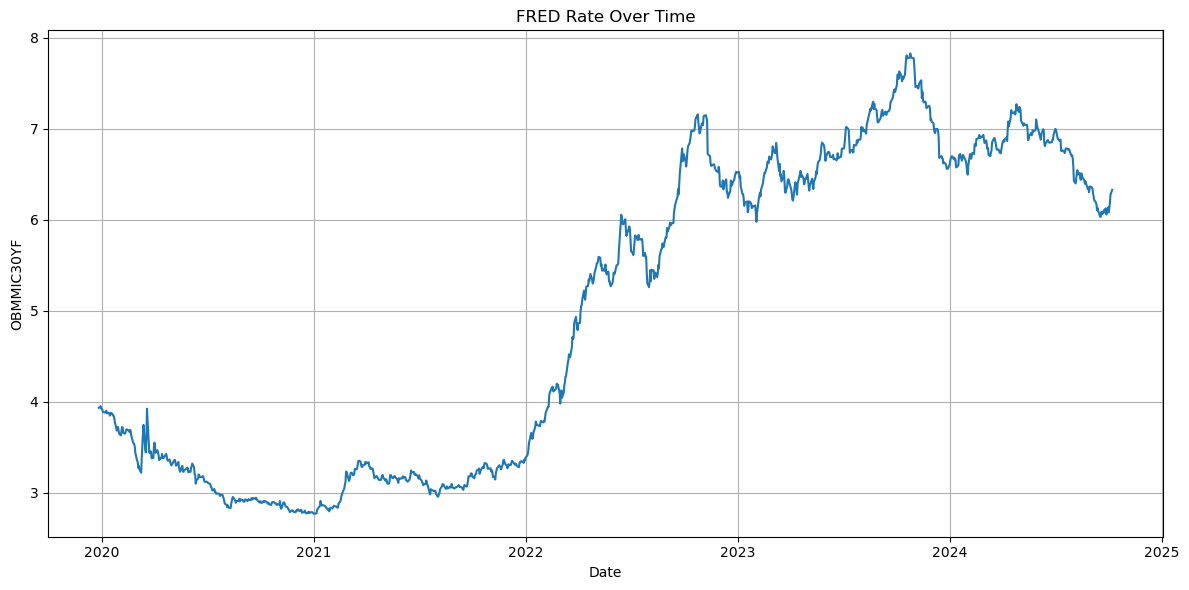

In [37]:
plt.figure(figsize=(12, 6))
plt.plot(fred['Date'], fred['OBMMIC30YF'])
plt.title('FRED Rate Over Time')
plt.xlabel('Date')
plt.ylabel('OBMMIC30YF')
plt.grid(True)
plt.tight_layout()
plt.show()

## Feature Engineering

###This step I work on generate extra features on fred rate data, the reason for doing this is so that I can generate enough insight on rolling statistics, lag feature, difference, percentage, MA before merging so that I can gain more enough insight without handling unnessessary NaN value later

In [10]:
y_hist = fred["OBMMIC30YF"].shift(1)

# Rolling mean and stdev
fred['OBM_roll3'] = fred['OBMMIC30YF'].rolling(3).mean()
fred['OBM_std3'] = fred['OBMMIC30YF'].rolling(3).std()
fred['OBM_roll5'] = fred['OBMMIC30YF'].rolling(5).mean()
fred['OBM_std5'] = fred['OBMMIC30YF'].rolling(5).std()
fred['OBM_roll7'] = fred['OBMMIC30YF'].rolling(7).mean()
fred['OBM_std7'] = fred['OBMMIC30YF'].rolling(7).std()

# Differences and percent changes
fred['OBM_diff'] = fred['OBMMIC30YF'].diff()

# Exponential moving average
fred['OBM_ewm3'] = fred['OBMMIC30YF'].ewm(span=3, adjust=False).mean()
fred['OBM_ewm5'] = fred['OBMMIC30YF'].ewm(span=5, adjust=False).mean()
fred['OBM_ewm7'] = fred['OBMMIC30YF'].ewm(span=7, adjust=False).mean()

# Add lag features
fred['OBM_lag1'] = fred['OBMMIC30YF'].shift(1)
fred['OBM_lag3'] = fred['OBMMIC30YF'].shift(3)
fred['OBM_lag5'] = fred['OBMMIC30YF'].shift(5)
fred['OBM_lag7'] = fred['OBMMIC30YF'].shift(7)

# Drop NaNs
fred.dropna(inplace=True)

In [11]:
yield_cols = ['3 Mo', '6 Mo', '1 Yr', '2 Yr', '3 Yr', '5 Yr', '7 Yr', '10 Yr', '20 Yr', '30 Yr']

for col in yield_cols:
    data[f'{col}_diff'] = data[col].diff()
    data[f'{col}_lag1'] = data[col].shift(1)
    data[f'{col}_lag3'] = data[col].shift(3)
    data[f'{col}_lag5'] = data[col].shift(5)
    data[f'{col}_lag7'] = data[col].shift(7)

data.dropna(inplace=True)

#Preprocessing step 2: Merging and generate insight from merged data


In [23]:
df = pd.merge(data, fred, on="Date", how="inner")
df = df.sort_values("Date").reset_index(drop=True)

df["target_next"] = df["OBMMIC30YF"].shift(-1)
df["target_change_next"] = (
    df["OBMMIC30YF"].shift(-1) - df["OBMMIC30YF"]
)


###Next I will work on mostly the treasury data where I can calculate all the relationship of yield curve Slops, Interaction between bonds yeild and generate date feature from date data

In [24]:
yield_cols = ['3 Mo', '6 Mo', '1 Yr', '2 Yr', '3 Yr', '5 Yr', '7 Yr', '10 Yr', '20 Yr', '30 Yr']

# Yield Curve Slopes
from itertools import combinations

for short, long in combinations(yield_cols, 2):
    slope_name = f"{short}_{long}_slope"
    merged_data[slope_name] = merged_data[long] - merged_data[short]
    merged_data[f"{slope_name}_diff"] = merged_data[slope_name].diff()


# Date-Based Features
merged_data['DayOfWeek'] = merged_data['Date'].dt.dayofweek
merged_data['Month'] = merged_data['Date'].dt.month
merged_data['Quarter'] = merged_data['Date'].dt.quarter


In [14]:
#Data after engineering
merged_data

,Date,1 Mo,2 Mo,3 Mo,6 Mo,1 Yr,2 Yr,3 Yr,5 Yr,7 Yr,...,7 Yr_30 Yr_slope_diff,10 Yr_20 Yr_slope,10 Yr_20 Yr_slope_diff,10 Yr_30 Yr_slope,10 Yr_30 Yr_slope_diff,20 Yr_30 Yr_slope,20 Yr_30 Yr_slope_diff,DayOfWeek,Month,Quarter
0,2020-01-16,1.54,1.56,1.55,1.56,1.54,1.58,1.58,1.63,1.73,...,NaN,0.30,NaN,0.45,NaN,0.15,NaN,3,1,1
1,2020-01-17,1.54,1.56,1.56,1.57,1.56,1.58,1.56,1.63,1.74,...,2.000000e-02,0.32,2.000000e-02,0.45,2.220446e-16,0.13,-0.02,4,1,1
2,2020-01-21,1.52,1.54,1.56,1.57,1.54,1.53,1.53,1.57,1.69,...,-1.000000e-02,0.32,0.000000e+00,0.45,0.000000e+00,0.13,0.00,1,1,1
3,2020-01-22,1.52,1.53,1.55,1.56,1.55,1.53,1.52,1.57,1.68,...,2.220446e-16,0.30,-2.000000e-02,0.45,2.220446e-16,0.15,0.02,2,1,1
4,2020-01-23,1.55,1.57,1.55,1.56,1.55,1.51,1.51,1.55,1.65,...,-1.000000e-02,0.29,-1.000000e-02,0.44,-1.000000e-02,0.15,0.00,3,1,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1179,2024-10-01,4.96,4.87,4.71,4.36,3.96,3.61,3.52,3.51,3.60,...,1.000000e-02,0.40,2.000000e-02,0.34,1.000000e-02,-0.06,-0.01,1,10,4
1180,2024-10-02,4.92,4.83,4.69,4.36,3.97,3.63,3.54,3.55,3.65,...,1.000000e-02,0.40,8.881784e-16,0.35,1.000000e-02,-0.05,0.01,2,10,4
1181,2024-10-03,4.99,4.85,4.68,4.37,4.02,3.70,3.62,3.62,3.71,...,-2.000000e-02,0.39,-1.000000e-02,0.33,-2.000000e-02,-0.06,-0.01,3,10,4
1182,2024-10-04,5.01,4.88,4.73,4.45,4.20,3.93,3.84,3.81,3.88,...,-9.000000e-02,0.35,-4.000000e-02,0.28,-5.000000e-02,-0.07,-0.01,4,10,4


In [25]:
merged_data = merged_data.dropna()

In [26]:
merged_data.replace([np.inf, -np.inf], 0, inplace=True)


,Date,1 Mo,2 Mo,3 Mo,6 Mo,1 Yr,2 Yr,3 Yr,5 Yr,7 Yr,...,7 Yr_30 Yr_slope_diff,10 Yr_20 Yr_slope,10 Yr_20 Yr_slope_diff,10 Yr_30 Yr_slope,10 Yr_30 Yr_slope_diff,20 Yr_30 Yr_slope,20 Yr_30 Yr_slope_diff,DayOfWeek,Month,Quarter
2,2020-01-21,1.52,1.54,1.56,1.57,1.54,1.53,1.53,1.57,1.69,...,-1.000000e-02,0.32,0.000000e+00,0.45,0.000000e+00,0.13,0.000000e+00,1,1,1
3,2020-01-22,1.52,1.53,1.55,1.56,1.55,1.53,1.52,1.57,1.68,...,2.220446e-16,0.30,-2.000000e-02,0.45,2.220446e-16,0.15,2.000000e-02,2,1,1
4,2020-01-23,1.55,1.57,1.55,1.56,1.55,1.51,1.51,1.55,1.65,...,-1.000000e-02,0.29,-1.000000e-02,0.44,-1.000000e-02,0.15,0.000000e+00,3,1,1
5,2020-01-24,1.54,1.55,1.54,1.55,1.55,1.49,1.48,1.51,1.61,...,-2.220446e-16,0.30,1.000000e-02,0.44,0.000000e+00,0.14,-1.000000e-02,4,1,1
6,2020-01-27,1.53,1.55,1.55,1.57,1.53,1.44,1.41,1.44,1.52,...,-2.220446e-16,0.30,-2.220446e-16,0.44,-4.440892e-16,0.14,-2.220446e-16,0,1,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1179,2024-10-01,4.96,4.87,4.71,4.36,3.96,3.61,3.52,3.51,3.60,...,1.000000e-02,0.40,2.000000e-02,0.34,1.000000e-02,-0.06,-1.000000e-02,1,10,4
1180,2024-10-02,4.92,4.83,4.69,4.36,3.97,3.63,3.54,3.55,3.65,...,1.000000e-02,0.40,8.881784e-16,0.35,1.000000e-02,-0.05,1.000000e-02,2,10,4
1181,2024-10-03,4.99,4.85,4.68,4.37,4.02,3.70,3.62,3.62,3.71,...,-2.000000e-02,0.39,-1.000000e-02,0.33,-2.000000e-02,-0.06,-1.000000e-02,3,10,4
1182,2024-10-04,5.01,4.88,4.73,4.45,4.20,3.93,3.84,3.81,3.88,...,-9.000000e-02,0.35,-4.000000e-02,0.28,-5.000000e-02,-0.07,-1.000000e-02,4,10,4


#**Predictive Modeling Step 2 Method**

##ACF and PACF plotting



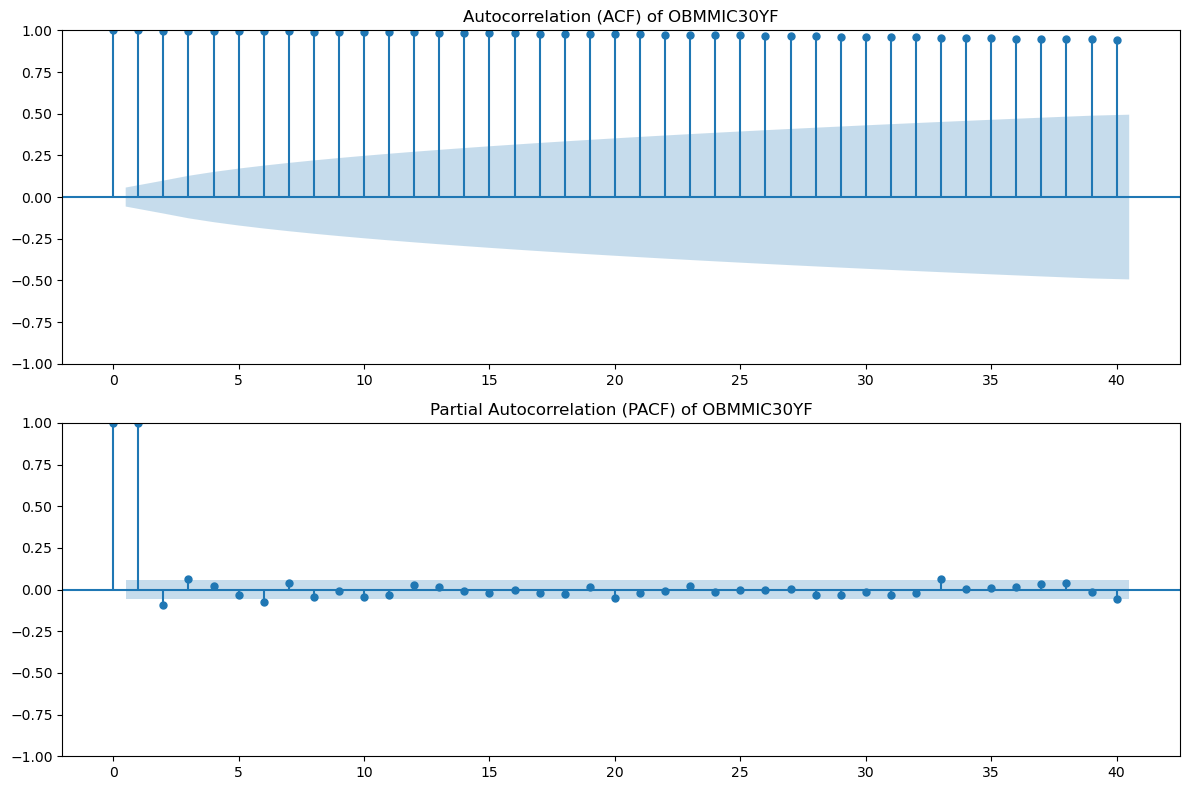

In [19]:
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

target_series = merged_data[['Date', 'OBMMIC30YF']].dropna().sort_values('Date')
y = target_series['OBMMIC30YF']

fig, ax = plt.subplots(2, 1, figsize=(12, 8))

plot_acf(y, lags=40, ax=ax[0])
ax[0].set_title("Autocorrelation (ACF) of OBMMIC30YF")

plot_pacf(y, lags=40, ax=ax[1], method='ywm')
ax[1].set_title("Partial Autocorrelation (PACF) of OBMMIC30YF")

plt.tight_layout()
plt.show()

###From the ACF and PACF graph I can see that there is slow decay after 40 days and show a slightly non-stationary therefore d = 1. For PACF there is drop at lag2 therefore p =2 at AR(2). For MA component there is slight sign which in this case I will take into consider at MA(1) model so q=1

##Before working on the modeling process I want to work on to reduce dimensionality since the ratio of features/length is too high and this will take in bias and overfitting, therefore applying PCA to remove collinearity and reduce dimensionality for model simplification

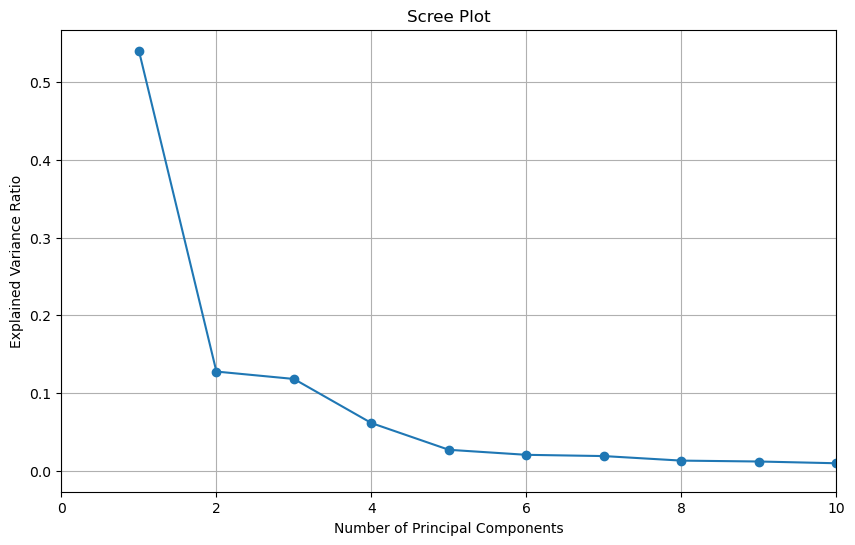

In [ ]:
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

scaler = StandardScaler()
pca = PCA(n_components=3)

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

X_train_pca = pca.fit_transform(X_train_scaled)
X_test_pca  = pca.transform(X_test_scaled)

# Scree plot
plt.figure(figsize=(10, 6))
plt.plot(np.arange(1, len(pca.explained_variance_ratio_) + 1),
         pca.explained_variance_ratio_, marker='o')
plt.title('Scree Plot')
plt.xlabel('Number of Principal Components')
plt.ylabel('Explained Variance Ratio')
plt.grid(True)
plt.xlim(0, 10)
plt.show()

## Linear Regression with 5PC

In [21]:
n_components = 2

pca = PCA(n_components=n_components)
X_pca = pca.fit_transform(X_scaled)


In [22]:
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

X_pca = sm.add_constant(X_pca)

model = sm.OLS(np.log1p(y), X_pca)
results = model.fit()

print(results.summary())

                            OLS Regression Results                            
Dep. Variable:             OBMMIC30YF   R-squared:                       0.955
Model:                            OLS   Adj. R-squared:                  0.955
Method:                 Least Squares   F-statistic:                 1.251e+04
Date:                Mon, 14 Sep 2026   Prob (F-statistic):               0.00
Time:                        20:05:10   Log-Likelihood:                 1582.7
No. Observations:                1183   AIC:                            -3159.
Df Residuals:                    1180   BIC:                            -3144.
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          1.7490      0.002    946.276      0.0

In [339]:
#remove pc2
keep_cols = [0, 1]

X_selected = X_pca[:, keep_cols]

model = sm.OLS(np.log1p(y), X_selected)
results = model.fit()

print(results.summary())

                            OLS Regression Results                            
Dep. Variable:             OBMMIC30YF   R-squared:                       0.963
Model:                            OLS   Adj. R-squared:                  0.963
Method:                 Least Squares   F-statistic:                 3.100e+04
Date:                Thu, 24 Apr 2025   Prob (F-statistic):               0.00
Time:                        23:30:00   Log-Likelihood:                 1706.2
No. Observations:                1184   AIC:                            -3408.
Df Residuals:                    1182   BIC:                            -3398.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          1.7466      0.002   1048.520      0.0

###This conclude our LR model with all feature is a good fit with significant level of 0.05 with low AIC, BIC number and good log likelihood, however there is a low durbin-watson, which I will proceed to work on the SARIMAX for better autocorrelation


## Model2: SARIMAX with 5PC

### For next I will work on applying the SARIMAX model in this case with tuning and comparison whether it is a better application than LR model

In [340]:
sarimax_pca = SARIMAX(np.log1p(y_train_pca), exog=X_train_pca, order=(2, 1, 1),
                      enforce_stationarity=False, enforce_invertibility=False)
sarimax_pca_fit = sarimax_pca.fit(disp=False)

y_pred_sarimax_pca = sarimax_pca_fit.forecast(steps=len(y_test_pca), exog=X_test_pca)

rmse_sarimax_pca = mean_squared_error(y_test_pca, y_pred_sarimax_pca)**0.5
r2_sarimax_pca = r2_score(y_test_pca, y_pred_sarimax_pca)

print(sarimax_pca_fit.summary())

print(f"SARIMAX with PCA - RMSE: {rmse_sarimax_pca:.4f}")
print(f"SARIMAX with PCA - R-squared: {r2_sarimax_pca:.4f}")

/usr/local/lib/python3.11/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: An unsupported index was provided. As a result, forecasts cannot be generated. To use the model for forecasting, use one of the supported classes of index.
  self._init_dates(dates, freq)
/usr/local/lib/python3.11/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: An unsupported index was provided. As a result, forecasts cannot be generated. To use the model for forecasting, use one of the supported classes of index.
  self._init_dates(dates, freq)


                               SARIMAX Results                                
Dep. Variable:             OBMMIC30YF   No. Observations:                  828
Model:               SARIMAX(2, 1, 1)   Log Likelihood                1984.401
Date:                Thu, 24 Apr 2025   AIC                          -3954.801
Time:                        23:30:12   BIC                          -3921.794
Sample:                             0   HQIC                         -3942.140
                                - 828                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const      -1.567e-10    1.5e-08     -0.010      0.992   -2.96e-08    2.93e-08
x1            -0.0114   8.48e-05   -134.573      0.000      -0.012      -0.011
x2         -1.571e-05      0.000     -0.089      0.9

/usr/local/lib/python3.11/dist-packages/statsmodels/tsa/base/tsa_model.py:837: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(
/usr/local/lib/python3.11/dist-packages/statsmodels/tsa/base/tsa_model.py:837: FutureWarning: No supported index is available. In the next version, calling this method in a model without a supported index will result in an exception.
  return get_prediction_index(


### This indicate a decent fit with high likelihood and low AIC/BIC, however there is a poor performance within the model given unsignificant pc2, pc4, pc5 pc with all the time series term. I will work on removing MA step or other feature if needed

In [341]:
keep_cols = [0, 1, 2]

X_selected = X_pca[:, keep_cols]
y = merged_data["OBMMIC30YF"]

X_train_pca, X_test_pca, y_train, y_test = train_test_split(
    X_selected, np.log1p(y), test_size=0.3, random_state=42)

model = SARIMAX(y_train,
                exog=X_train_pca,
                order=(0, 1, 1),
                enforce_stationarity=False,
                enforce_invertibility=False)
fit = model.fit(disp=False, cov_type='robust')
print(fit.summary())

/usr/local/lib/python3.11/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: An unsupported index was provided. As a result, forecasts cannot be generated. To use the model for forecasting, use one of the supported classes of index.
  self._init_dates(dates, freq)
/usr/local/lib/python3.11/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: An unsupported index was provided. As a result, forecasts cannot be generated. To use the model for forecasting, use one of the supported classes of index.
  self._init_dates(dates, freq)


                               SARIMAX Results                                
Dep. Variable:             OBMMIC30YF   No. Observations:                  828
Model:               SARIMAX(0, 1, 1)   Log Likelihood                1128.943
Date:                Thu, 24 Apr 2025   AIC                          -2247.887
Time:                        23:30:18   BIC                          -2224.310
Sample:                             0   HQIC                         -2238.843
                                - 828                                         
Covariance Type:               robust                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const      -3.304e-11          0       -inf      0.000    -3.3e-11    -3.3e-11
x1             0.0308      0.000    177.745      0.000       0.030       0.031
x2             0.0023      0.000      4.640      0.0

/usr/local/lib/python3.11/dist-packages/statsmodels/tsa/statespace/mlemodel.py:3016: RuntimeWarning: divide by zero encountered in divide
  return self.params / self.bse


### yield a strong result with significant Ljung-Box stat along with high log likelihood, however with log JB score, this require backtesting with GARCH


In [342]:
!pip install arch
from arch import arch_model

In [343]:
resid = fit.resid.dropna()

garch_model = arch_model(resid, vol='Garch', p=1, q=1)
garch_fit = garch_model.fit(disp='off')
print(garch_fit.summary())

                     Constant Mean - GARCH Model Results                      
Dep. Variable:                   None   R-squared:                       0.000
Mean Model:             Constant Mean   Adj. R-squared:                  0.000
Vol Model:                      GARCH   Log-Likelihood:                1115.65
Distribution:                  Normal   AIC:                          -2223.30
Method:            Maximum Likelihood   BIC:                          -2204.43
                                        No. Observations:                  828
Date:                Thu, Apr 24 2025   Df Residuals:                      827
Time:                        23:30:31   Df Model:                            1
                                  Mean Model                                  
                  coef    std err          t      P>|t|       95.0% Conf. Int.
------------------------------------------------------------------------------
mu         -1.2977e-03  2.454e-03     -0.529      0.

/usr/local/lib/python3.11/dist-packages/arch/univariate/base.py:309: DataScaleWarning: y is poorly scaled, which may affect convergence of the optimizer when
estimating the model parameters. The scale of y is 0.008262. Parameter
estimation work better when this value is between 1 and 1000. The recommended
rescaling is 10 * y.

This warning can be disabled by either rescaling y before initializing the
model or by setting rescale=False.

  warnings.warn(


### garch is not needed in this case. I can keep (0,1,1) model for forecasting

###In this case I successfully predict accurately based on clean data, and decide to apply to prediction for faster run time and easier to work on tuning process and can be taken further for Boosting method. However I still need to check on the performance on unseen data, therefore in this case I apply 3 method of testing.

Treasury rows: 1195
Mortgage rows: 1247
Merged rows: 1194
Merged date range: 2020-01-02 to 2024-10-07

Usable modeling rows: 1076
Modeling range: 2020-01-31 to 2024-10-04

Stationarity tests
                 series  ADF_stat  ADF_pvalue  KPSS_stat  KPSS_pvalue
    Mortgage rate level   -0.5616      0.8794     5.1245         0.01
Mortgage rate 1d change   -6.1832      0.0000     0.3378         0.10
     10Y Treasury level   -0.4988      0.8923     5.3878         0.01
 10Y Treasury 1d change  -26.3027      0.0000     0.1874         0.10

Chronological holdout
Train: 2020-01-31 to 2023-10-11 (860 rows)
Test : 2023-10-12 to 2024-10-04 (216 rows)

PCA explained variance (fit on train only)
curve_PC1    0.7107
curve_PC2    0.1596
curve_PC3    0.0794

Treasury-change PCA loadings
       curve_PC1  curve_PC2  curve_PC3
3 Mo       0.175      0.491      0.636
6 Mo       0.258      0.491      0.187
1 Yr       0.298      0.368     -0.252
2 Yr       0.337      0.167     -0.368
3 Yr       0.353     

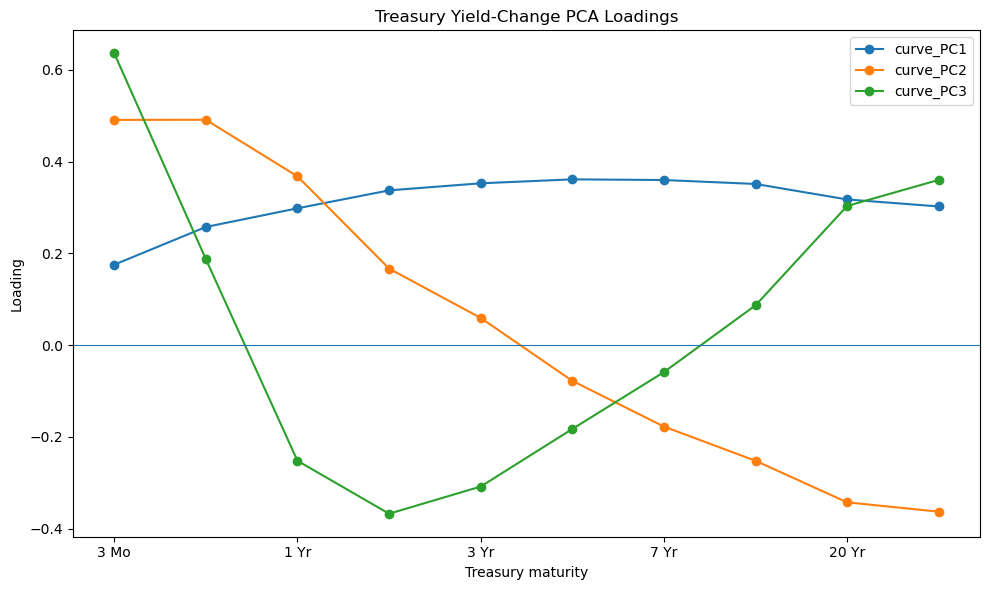

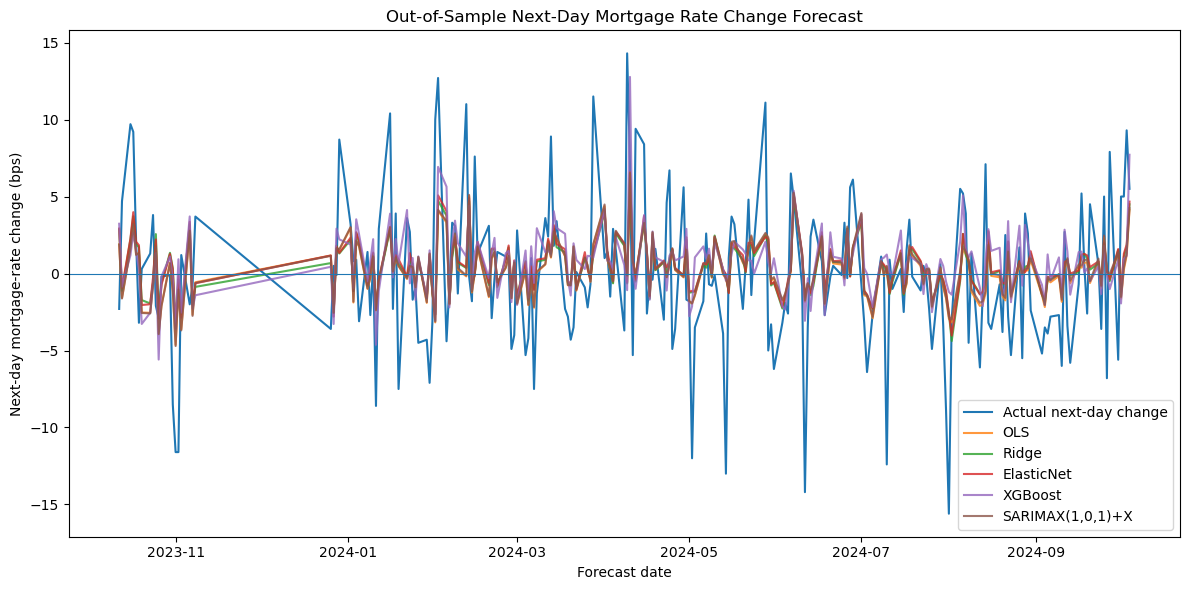

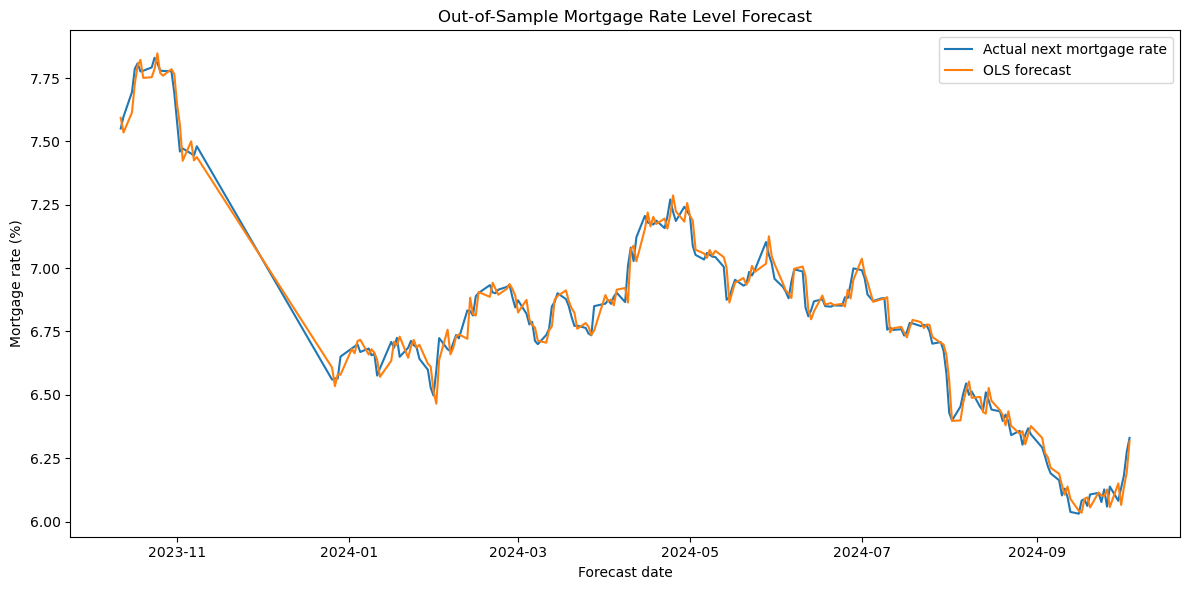


Saved outputs to: /Users/vanpan/Desktop/results

Best holdout non-baseline model: OLS
Holdout RMSE improvement vs random walk: 5.88%
Interpretation: the best model beat the random-walk benchmark on holdout RMSE. Confirm that the improvement is also stable across walk-forward folds before claiming predictive edge.


In [ ]:
# =========================
# 0. Imports / configuration
# =========================
import warnings
warnings.filterwarnings("ignore")

from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from scipy import stats

from sklearn.base import clone
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression, Ridge, ElasticNet
from sklearn.ensemble import HistGradientBoostingRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import TimeSeriesSplit

from statsmodels.tsa.stattools import adfuller, kpss
from statsmodels.stats.diagnostic import acorr_ljungbox, het_arch
from statsmodels.tsa.statespace.sarimax import SARIMAX
import statsmodels.api as sm


# ----- Change this path only if the file lives somewhere else -----
_uploaded = Path("/mnt/data/Data Project.xlsx")
DATA_PATH = _uploaded if _uploaded.exists() else Path("Data Project.xlsx")

TREASURY_SHEET = "Data Project"
MORTGAGE_SHEET = "FRED Rate"

TEST_FRACTION = 0.20
N_WALK_FORWARD_SPLITS = 5
RANDOM_STATE = 42

YIELD_COLS = [
    "1 Mo", "2 Mo", "3 Mo", "6 Mo", "1 Yr", "2 Yr",
    "3 Yr", "5 Yr", "7 Yr", "10 Yr", "20 Yr", "30 Yr"
]

# PCA will be applied to daily CHANGES of these maturities.
PCA_YIELD_COLS = [
    "3 Mo", "6 Mo", "1 Yr", "2 Yr", "3 Yr",
    "5 Yr", "7 Yr", "10 Yr", "20 Yr", "30 Yr"
]


# =========================
# 1. Load and clean workbook
# =========================
def load_data(path: Path) -> pd.DataFrame:
    treasury = pd.read_excel(path, sheet_name=TREASURY_SHEET, header=1)
    mortgage = pd.read_excel(path, sheet_name=MORTGAGE_SHEET, header=1)

    # Standardize date names/types.
    treasury = treasury.rename(columns={"Date": "Date"})
    mortgage = mortgage.rename(columns={"DATE": "Date"})

    treasury["Date"] = pd.to_datetime(treasury["Date"], errors="coerce")
    mortgage["Date"] = pd.to_datetime(mortgage["Date"], errors="coerce")

    # Coerce numeric columns. FRED uses "." for some missing observations.
    for col in YIELD_COLS:
        treasury[col] = pd.to_numeric(treasury[col], errors="coerce")

    mortgage["OBMMIC30YF"] = pd.to_numeric(
        mortgage["OBMMIC30YF"], errors="coerce"
    )

    # CRITICAL: sort BEFORE any diff/shift/rolling operations.
    treasury = (
        treasury.dropna(subset=["Date"])
        .sort_values("Date")
        .drop_duplicates("Date", keep="last")
        .reset_index(drop=True)
    )

    mortgage = (
        mortgage.dropna(subset=["Date"])
        .sort_values("Date")
        .drop_duplicates("Date", keep="last")
        .reset_index(drop=True)
    )

    assert treasury["Date"].is_monotonic_increasing
    assert mortgage["Date"].is_monotonic_increasing

    # Merge only days observed in both datasets.
    df = pd.merge(treasury, mortgage, on="Date", how="inner")
    df = df.sort_values("Date").reset_index(drop=True)

    print("Treasury rows:", len(treasury))
    print("Mortgage rows:", len(mortgage))
    print("Merged rows:", len(df))
    print("Merged date range:", df["Date"].min().date(), "to", df["Date"].max().date())

    return df


# =========================
# 2. Feature engineering
# =========================
def engineer_features(df: pd.DataFrame) -> pd.DataFrame:
    out = df.copy()

    # ----- Daily/weekly Treasury changes -----
    for col in YIELD_COLS:
        safe = col.replace(" ", "_")
        out[f"{safe}_chg1"] = out[col].diff(1)
        out[f"{safe}_chg5"] = out[col].diff(5)

    # ----- Economically interpretable curve features -----
    out["2s10s"] = out["10 Yr"] - out["2 Yr"]
    out["3m10y"] = out["10 Yr"] - out["3 Mo"]
    out["5s30s"] = out["30 Yr"] - out["5 Yr"]

    # A simple "belly vs wings" curvature proxy.
    out["curve_curvature_2_5_10"] = (
        2.0 * out["5 Yr"] - out["2 Yr"] - out["10 Yr"]
    )

    # ----- Mortgage dynamics known at t -----
    out["mortgage_chg1"] = out["OBMMIC30YF"].diff(1)
    out["mortgage_chg5"] = out["OBMMIC30YF"].diff(5)

    out["mortgage_ma5"] = out["OBMMIC30YF"].rolling(5).mean()
    out["mortgage_ma20"] = out["OBMMIC30YF"].rolling(20).mean()
    out["mortgage_vol5"] = out["mortgage_chg1"].rolling(5).std()
    out["mortgage_vol20"] = out["mortgage_chg1"].rolling(20).std()

    # Mortgage minus Treasury spread at date t.
    out["mortgage_10y_spread"] = out["OBMMIC30YF"] - out["10 Yr"]
    out["mortgage_10y_spread_chg1"] = out["mortgage_10y_spread"].diff(1)
    out["mortgage_10y_spread_ma20"] = (out["mortgage_10y_spread"].rolling(20).mean())

    # ----- PCA input: daily Treasury yield changes -----
    for col in PCA_YIELD_COLS:
        safe = col.replace(" ", "_")
        out[f"pca_{safe}_chg1"] = out[col].diff(1)

    # ----- One-step-ahead target -----
    out["mortgage_next"] = out["OBMMIC30YF"].shift(-1)
    out["target_change_next"] = (
        out["mortgage_next"] - out["OBMMIC30YF"]
    )

    # Keep the current rate separately so predicted changes can be
    # reconstructed into predicted next-day levels.
    out["current_mortgage_rate"] = out["OBMMIC30YF"]

    return out


PCA_INPUT_COLS = [
    f"pca_{c.replace(' ', '_')}_chg1" for c in PCA_YIELD_COLS
]

ECON_FEATURES = [
    # Curve shape
    "2s10s", "3m10y", "5s30s", "curve_curvature_2_5_10",

    # Key Treasury moves
    "2_Yr_chg1", "5_Yr_chg1", "10_Yr_chg1", "30_Yr_chg1",
    "2_Yr_chg5", "5_Yr_chg5", "10_Yr_chg5", "30_Yr_chg5",

    # Mortgage dynamics
    "mortgage_chg1", "mortgage_chg5",
    "mortgage_vol5", "mortgage_vol20",

    # Mortgage/Treasury spread dynamics
    "mortgage_10y_spread",
    "mortgage_10y_spread_chg1",
    "mortgage_10y_spread_ma20",
]


def prepare_model_frame(featured: pd.DataFrame) -> pd.DataFrame:
    required = (
        ["Date", "target_change_next", "mortgage_next", "current_mortgage_rate"]
        + ECON_FEATURES
        + PCA_INPUT_COLS
    )

    model_df = (
        featured[required]
        .replace([np.inf, -np.inf], np.nan)
        .dropna()
        .sort_values("Date")
        .reset_index(drop=True)
    )

    print("\nUsable modeling rows:", len(model_df))
    print("Modeling range:", model_df["Date"].min().date(), "to", model_df["Date"].max().date())

    return model_df


# =========================================
# 3. Stationarity + time-series diagnostics
# =========================================
def stationarity_tests(series: pd.Series, name: str) -> dict:
    x = pd.Series(series).dropna()

    adf = adfuller(x, autolag="AIC")
    kpss_result = kpss(x, regression="c", nlags="auto")

    result = {
        "series": name,
        "ADF_stat": adf[0],
        "ADF_pvalue": adf[1],
        "KPSS_stat": kpss_result[0],
        "KPSS_pvalue": kpss_result[1],
    }
    return result


def run_stationarity_report(featured: pd.DataFrame) -> pd.DataFrame:
    rows = [
        stationarity_tests(featured["OBMMIC30YF"], "Mortgage rate level"),
        stationarity_tests(featured["OBMMIC30YF"].diff(), "Mortgage rate 1d change"),
        stationarity_tests(featured["10 Yr"], "10Y Treasury level"),
        stationarity_tests(featured["10 Yr"].diff(), "10Y Treasury 1d change"),
    ]
    report = pd.DataFrame(rows)
    print("\nStationarity tests")
    print(report.round(4).to_string(index=False))
    return report


# =========================
# 4. Leakage-safe curve PCA
# =========================
def fit_curve_pca(
    train_df: pd.DataFrame,
    test_df: pd.DataFrame,
    n_components: int = 3
):
    scaler = StandardScaler()
    pca = PCA(n_components=n_components)

    z_train = scaler.fit_transform(train_df[PCA_INPUT_COLS])
    z_test = scaler.transform(test_df[PCA_INPUT_COLS])

    pc_train = pca.fit_transform(z_train)
    pc_test = pca.transform(z_test)

    pc_cols = [f"curve_PC{i+1}" for i in range(n_components)]

    pc_train = pd.DataFrame(
        pc_train, columns=pc_cols, index=train_df.index
    )
    pc_test = pd.DataFrame(
        pc_test, columns=pc_cols, index=test_df.index
    )

    loadings = pd.DataFrame(
        pca.components_.T,
        index=PCA_YIELD_COLS,
        columns=pc_cols
    )

    explained = pd.Series(
        pca.explained_variance_ratio_,
        index=pc_cols,
        name="explained_variance_ratio"
    )

    return pc_train, pc_test, scaler, pca, loadings, explained


def make_design_matrices(train_df, test_df):
    pc_train, pc_test, scaler, pca, loadings, explained = fit_curve_pca(
        train_df, test_df, n_components=3
    )

    X_train = train_df[ECON_FEATURES].copy()
    X_test = test_df[ECON_FEATURES].copy()

    for c in pc_train.columns:
        X_train[c] = pc_train[c].values
        X_test[c] = pc_test[c].values

    y_train = train_df["target_change_next"].copy()
    y_test = test_df["target_change_next"].copy()

    return (
        X_train, X_test, y_train, y_test,
        scaler, pca, loadings, explained
    )


# =========================
# 5. Forecast metrics
# =========================
def evaluate_predictions(
    y_true,
    y_pred,
    current_rate=None,
    next_rate=None
) -> dict:
    y_true = np.asarray(y_true, dtype=float)
    y_pred = np.asarray(y_pred, dtype=float)

    out = {
        "MAE_bps": mean_absolute_error(y_true, y_pred) * 100.0,
        "RMSE_bps": np.sqrt(mean_squared_error(y_true, y_pred)) * 100.0,
        "R2_change": r2_score(y_true, y_pred),
        "Directional_Accuracy": (
            np.mean(np.sign(y_true) == np.sign(y_pred))
            if np.any(np.abs(y_pred) > 1e-12)
            else np.nan
        ),
        "Forecast_Correlation": (
            np.corrcoef(y_true, y_pred)[0, 1]
            if np.std(y_pred) > 0 and np.std(y_true) > 0
            else np.nan
        )
    }

    # Convert predicted change back into next-day mortgage level.
    if current_rate is not None and next_rate is not None:
        current_rate = np.asarray(current_rate, dtype=float)
        next_rate = np.asarray(next_rate, dtype=float)
        predicted_next_level = current_rate + y_pred

        out["Next_Level_MAE_bps"] = (
            mean_absolute_error(next_rate, predicted_next_level) * 100.0
        )
        out["Next_Level_RMSE_bps"] = (
            np.sqrt(mean_squared_error(next_rate, predicted_next_level)) * 100.0
        )

    return out


def diebold_mariano_squared_error(y_true, pred_model, pred_benchmark):
    y_true = np.asarray(y_true)
    e_model = (y_true - np.asarray(pred_model)) ** 2
    e_bench = (y_true - np.asarray(pred_benchmark)) ** 2

    d = e_model - e_bench
    n = len(d)

    if n < 3 or np.std(d, ddof=1) == 0:
        return np.nan, np.nan

    stat = np.mean(d) / (np.std(d, ddof=1) / np.sqrt(n))
    pvalue = 2 * (1 - stats.norm.cdf(abs(stat)))
    return stat, pvalue


# =========================
# 6. Models
# =========================
def get_ml_models():
    models = {
        "OLS": Pipeline([
            ("scale", StandardScaler()),
            ("model", LinearRegression())
        ]),

        "Ridge": Pipeline([
            ("scale", StandardScaler()),
            ("model", Ridge(alpha=100.0))
        ]),

        "ElasticNet": Pipeline([
            ("scale", StandardScaler()),
            ("model", ElasticNet(
                alpha=0.001,
                l1_ratio=0.30,
                max_iter=20000,
                random_state=RANDOM_STATE
            ))
        ]),
    }

    if HAS_XGBOOST:
        models["XGBoost"] = XGBRegressor(
            n_estimators=300,
            max_depth=2,
            learning_rate=0.03,
            subsample=0.80,
            colsample_bytree=0.80,
            reg_alpha=0.10,
            reg_lambda=2.0,
            objective="reg:squarederror",
            random_state=RANDOM_STATE,
            n_jobs=4
        )
    else:
        models["HistGradientBoosting"] = HistGradientBoostingRegressor(
            max_iter=300,
            learning_rate=0.04,
            max_leaf_nodes=15,
            l2_regularization=2.0,
            random_state=RANDOM_STATE
        )

    return models


def rolling_one_step_sarimax(
    y_train: pd.Series,
    X_train: pd.DataFrame,
    y_test: pd.Series,
    X_test: pd.DataFrame,
    order=(1, 0, 1)
):
    model = SARIMAX(
        y_train,
        exog=X_train,
        order=order,
        trend="c",
        enforce_stationarity=False,
        enforce_invertibility=False
    )

    results = model.fit(disp=False, maxiter=300)
    preds = []

    for i in range(len(y_test)):
        x_i = X_test.iloc[[i]]

        pred = results.get_forecast(
            steps=1,
            exog=x_i
        ).predicted_mean.iloc[0]

        preds.append(float(pred))

        # Update the filter with the actual observation, without re-estimating
        # all model coefficients.
        new_y = pd.Series(
            [y_test.iloc[i]],
            index=[y_test.index[i]],
            name=y_train.name
        )

        results = results.append(
            endog=new_y,
            exog=x_i,
            refit=False
        )

    return np.asarray(preds), model, results


# =========================
# 7. Holdout evaluation
# =========================
def chronological_holdout(model_df: pd.DataFrame):
    split = int(len(model_df) * (1.0 - TEST_FRACTION))

    train_df = model_df.iloc[:split].copy()
    test_df = model_df.iloc[split:].copy()

    assert train_df["Date"].max() < test_df["Date"].min()

    print("\nChronological holdout")
    print("Train:", train_df["Date"].min().date(), "to", train_df["Date"].max().date(),
          f"({len(train_df)} rows)")
    print("Test :", test_df["Date"].min().date(), "to", test_df["Date"].max().date(),
          f"({len(test_df)} rows)")

    (
        X_train, X_test, y_train, y_test,
        pca_scaler, pca, loadings, explained
    ) = make_design_matrices(train_df, test_df)

    print("\nPCA explained variance (fit on train only)")
    print(explained.round(4).to_string())

    print("\nTreasury-change PCA loadings")
    print(loadings.round(3).to_string())

    predictions = {}
    rows = []

    # Random-walk benchmark: next change = 0.
    predictions["Random Walk"] = np.zeros(len(y_test))

    benchmark_metrics = evaluate_predictions(
        y_test,
        predictions["Random Walk"],
        current_rate=test_df["current_mortgage_rate"],
        next_rate=test_df["mortgage_next"]
    )
    rows.append({"Model": "Random Walk", **benchmark_metrics})

    # Machine-learning/statistical regressions.
    fitted_models = {}
    for name, model in get_ml_models().items():
        fitted = clone(model)
        fitted.fit(X_train, y_train)
        pred = fitted.predict(X_test)

        predictions[name] = np.asarray(pred)
        fitted_models[name] = fitted

        metrics = evaluate_predictions(
            y_test,
            pred,
            current_rate=test_df["current_mortgage_rate"],
            next_rate=test_df["mortgage_next"]
        )
        rows.append({"Model": name, **metrics})

    # SARIMAX benefits from standardizing exogenous variables.
    sarimax_scaler = StandardScaler()
    X_train_s = pd.DataFrame(
        sarimax_scaler.fit_transform(X_train),
        columns=X_train.columns,
        index=X_train.index
    )
    X_test_s = pd.DataFrame(
        sarimax_scaler.transform(X_test),
        columns=X_test.columns,
        index=X_test.index
    )

    try:
        sarimax_pred, _, sarimax_results = rolling_one_step_sarimax(
            y_train=y_train,
            X_train=X_train_s,
            y_test=y_test,
            X_test=X_test_s,
            order=(1, 0, 1)
        )

        predictions["SARIMAX(1,0,1)+X"] = sarimax_pred

        sarimax_metrics = evaluate_predictions(
            y_test,
            sarimax_pred,
            current_rate=test_df["current_mortgage_rate"],
            next_rate=test_df["mortgage_next"]
        )
        rows.append({
            "Model": "SARIMAX(1,0,1)+X",
            **sarimax_metrics
        })
    except Exception as exc:
        sarimax_results = None
        print("\nSARIMAX failed:", repr(exc))

    results_df = pd.DataFrame(rows)
    results_df = results_df.sort_values("RMSE_bps").reset_index(drop=True)

    # Predictive-accuracy test against random walk.
    dm_rows = []
    for name, pred in predictions.items():
        if name == "Random Walk":
            continue
        dm_stat, dm_p = diebold_mariano_squared_error(
            y_test,
            pred,
            predictions["Random Walk"]
        )
        dm_rows.append({
            "Model": name,
            "DM_stat_vs_RW": dm_stat,
            "DM_pvalue_vs_RW": dm_p
        })

    dm_df = pd.DataFrame(dm_rows)

    print("\nHoldout model comparison")
    print(results_df.round(4).to_string(index=False))

    print("\nPredictive accuracy vs Random Walk")
    if len(dm_df):
        print(dm_df.round(4).to_string(index=False))

    return {
        "train_df": train_df,
        "test_df": test_df,
        "X_train": X_train,
        "X_test": X_test,
        "y_train": y_train,
        "y_test": y_test,
        "loadings": loadings,
        "explained": explained,
        "predictions": predictions,
        "fitted_models": fitted_models,
        "sarimax_results": sarimax_results,
        "results_df": results_df,
        "dm_df": dm_df,
    }


# ============================================
# 8. Expanding-window walk-forward validation
# ============================================
def walk_forward_validation(
    model_df: pd.DataFrame,
    initial_train_fraction: float = 0.60,
    test_window: int = 80
):
    n = len(model_df)
    initial_train_size = int(n * initial_train_fraction)

    all_rows = []
    fold = 1
    test_start = initial_train_size

    while test_start < n:
        test_end = min(test_start + test_window, n)

        train_df = model_df.iloc[:test_start].copy()
        test_df = model_df.iloc[test_start:test_end].copy()

        (
            X_train, X_test, y_train, y_test,
            _, _, _, _
        ) = make_design_matrices(train_df, test_df)

        # Random-walk benchmark
        baseline = np.zeros(len(y_test))
        metrics = evaluate_predictions(
            y_test,
            baseline,
            current_rate=test_df["current_mortgage_rate"],
            next_rate=test_df["mortgage_next"]
        )
        all_rows.append({
            "Fold": fold,
            "Model": "Random Walk",
            "Train_Start": train_df["Date"].min(),
            "Train_End": train_df["Date"].max(),
            "Test_Start": test_df["Date"].min(),
            "Test_End": test_df["Date"].max(),
            **metrics
        })

        for name, model in get_ml_models().items():
            fitted = clone(model)
            fitted.fit(X_train, y_train)
            pred = fitted.predict(X_test)

            metrics = evaluate_predictions(
                y_test,
                pred,
                current_rate=test_df["current_mortgage_rate"],
                next_rate=test_df["mortgage_next"]
            )

            all_rows.append({
                "Fold": fold,
                "Model": name,
                "Train_Start": train_df["Date"].min(),
                "Train_End": train_df["Date"].max(),
                "Test_Start": test_df["Date"].min(),
                "Test_End": test_df["Date"].max(),
                **metrics
            })

        fold += 1
        test_start = test_end

    fold_results = pd.DataFrame(all_rows)

    summary = (
        fold_results
        .groupby("Model", as_index=False)
        .agg(
            Avg_MAE_bps=("MAE_bps", "mean"),
            Avg_RMSE_bps=("RMSE_bps", "mean"),
            Avg_R2_change=("R2_change", "mean"),
            Avg_Directional_Accuracy=("Directional_Accuracy", "mean"),
            Avg_Next_Level_RMSE_bps=("Next_Level_RMSE_bps", "mean")
        )
        .sort_values("Avg_RMSE_bps")
        .reset_index(drop=True)
    )

    print("\nWalk-forward validation summary")
    print(summary.round(4).to_string(index=False))

    return fold_results, summary


# ============================================
# 9. Linear-model inference on training sample
# ============================================
def fit_inference_ols(X_train: pd.DataFrame, y_train: pd.Series):
    """
    Statsmodels OLS for coefficient/t-stat inspection.
    HAC standard errors are used because financial time series may retain
    mild serial dependence / heteroskedasticity.
    """
    scaler = StandardScaler()
    Xz = pd.DataFrame(
        scaler.fit_transform(X_train),
        columns=X_train.columns,
        index=X_train.index
    )

    Xz = sm.add_constant(Xz)

    model = sm.OLS(y_train, Xz).fit(
        cov_type="HAC",
        cov_kwds={"maxlags": 5}
    )

    coef_table = pd.DataFrame({
        "coef": model.params,
        "std_err_HAC": model.bse,
        "t_stat": model.tvalues,
        "p_value": model.pvalues
    }).sort_values("p_value")

    print("\nOLS inference with HAC standard errors")
    print(coef_table.head(15).round(5).to_string())

    return model, coef_table, scaler


# ============================================
# 10. Residual diagnostics
# ============================================
def residual_diagnostics(y_true, y_pred, model_name="Best model"):
    resid = pd.Series(
        np.asarray(y_true) - np.asarray(y_pred)
    ).dropna()

    lb = acorr_ljungbox(
        resid,
        lags=[5, 10],
        return_df=True
    )

    arch_lm = het_arch(resid, nlags=min(10, max(1, len(resid) // 10)))

    jb = stats.jarque_bera(resid)

    print(f"\nResidual diagnostics: {model_name}")
    print("\nLjung-Box")
    print(lb.round(4).to_string())

    print("\nARCH LM")
    print("LM statistic:", round(float(arch_lm[0]), 4))
    print("LM p-value :", round(float(arch_lm[1]), 4))

    print("\nJarque-Bera")
    print("JB statistic:", round(float(jb.statistic), 4))
    print("JB p-value :", round(float(jb.pvalue), 4))

    return {
        "residuals": resid,
        "ljung_box": lb,
        "arch_lm_stat": arch_lm[0],
        "arch_lm_pvalue": arch_lm[1],
        "jarque_bera_stat": jb.statistic,
        "jarque_bera_pvalue": jb.pvalue,
    }


# =========================
# 11. Plots
# =========================
def plot_pca_loadings(loadings: pd.DataFrame):
    ax = loadings.plot(
        marker="o",
        figsize=(10, 6),
        title="Treasury Yield-Change PCA Loadings"
    )
    ax.set_xlabel("Treasury maturity")
    ax.set_ylabel("Loading")
    ax.axhline(0, linewidth=0.8)
    plt.tight_layout()
    plt.show()


def plot_holdout_forecast(test_df, y_test, predictions):
    # Plot changes in basis points.
    plt.figure(figsize=(12, 6))
    plt.plot(
        test_df["Date"],
        np.asarray(y_test) * 100,
        label="Actual next-day change",
        linewidth=1.5
    )

    for name, pred in predictions.items():
        if name == "Random Walk":
            continue
        plt.plot(
            test_df["Date"],
            np.asarray(pred) * 100,
            label=name,
            alpha=0.8
        )

    plt.axhline(0, linewidth=0.8)
    plt.ylabel("Next-day mortgage-rate change (bps)")
    plt.xlabel("Forecast date")
    plt.title("Out-of-Sample Next-Day Mortgage Rate Change Forecast")
    plt.legend()
    plt.tight_layout()
    plt.show()


def plot_best_level_forecast(test_df, best_pred, best_name):
    actual_next = test_df["mortgage_next"].to_numpy()
    predicted_next = (
        test_df["current_mortgage_rate"].to_numpy()
        + np.asarray(best_pred)
    )

    plt.figure(figsize=(12, 6))
    plt.plot(
        test_df["Date"],
        actual_next,
        label="Actual next mortgage rate"
    )
    plt.plot(
        test_df["Date"],
        predicted_next,
        label=f"{best_name} forecast"
    )
    plt.ylabel("Mortgage rate (%)")
    plt.xlabel("Forecast date")
    plt.title("Out-of-Sample Mortgage Rate Level Forecast")
    plt.legend()
    plt.tight_layout()
    plt.show()


# =========================
# 12. Main execution
# =========================
def main():
    if not DATA_PATH.exists():
        raise FileNotFoundError(
            f"Could not find {DATA_PATH.resolve()}. "
            "Place Data Project.xlsx in the working directory or update DATA_PATH."
        )

    # Load + engineer
    raw = load_data(DATA_PATH)
    featured = engineer_features(raw)
    model_df = prepare_model_frame(featured)

    # Descriptive diagnostics
    stationarity_report = run_stationarity_report(featured)

    # Primary chronological holdout
    holdout = chronological_holdout(model_df)

    # Walk-forward robustness
    fold_results, walk_forward_summary = walk_forward_validation(
        model_df,
        initial_train_fraction=0.60,
        test_window=80
    )

    # Inference-oriented OLS using train only
    ols_model, coef_table, inference_scaler = fit_inference_ols(
        holdout["X_train"],
        holdout["y_train"]
    )

    # Pick best non-baseline holdout model by RMSE.
    result_non_baseline = holdout["results_df"][
        holdout["results_df"]["Model"] != "Random Walk"
    ]

    if len(result_non_baseline):
        best_name = result_non_baseline.iloc[0]["Model"]
    else:
        best_name = "Random Walk"

    best_pred = holdout["predictions"][best_name]

    diagnostics = residual_diagnostics(
        holdout["y_test"],
        best_pred,
        model_name=best_name
    )

    # Plots
    plot_pca_loadings(holdout["loadings"])
    plot_holdout_forecast(
        holdout["test_df"],
        holdout["y_test"],
        holdout["predictions"]
    )
    plot_best_level_forecast(
        holdout["test_df"],
        best_pred,
        best_name
    )

    # Save research outputs.
    output_dir = Path("results")
    output_dir.mkdir(exist_ok=True)

    holdout["results_df"].to_csv(
        output_dir / "holdout_model_comparison.csv",
        index=False
    )
    holdout["dm_df"].to_csv(
        output_dir / "diebold_mariano_vs_random_walk.csv",
        index=False
    )
    fold_results.to_csv(
        output_dir / "walk_forward_folds.csv",
        index=False
    )
    walk_forward_summary.to_csv(
        output_dir / "walk_forward_summary.csv",
        index=False
    )
    holdout["loadings"].to_csv(
        output_dir / "pca_loadings.csv"
    )
    coef_table.to_csv(
        output_dir / "ols_hac_coefficients.csv"
    )
    stationarity_report.to_csv(
        output_dir / "stationarity_tests.csv",
        index=False
    )

    forecast_output = holdout["test_df"][
        ["Date", "current_mortgage_rate", "mortgage_next", "target_change_next"]
    ].copy()

    for name, pred in holdout["predictions"].items():
        safe_name = (
            name.lower()
            .replace(" ", "_")
            .replace("(", "")
            .replace(")", "")
            .replace(",", "_")
            .replace("+", "_")
        )
        forecast_output[f"{safe_name}_pred_change"] = pred
        forecast_output[f"{safe_name}_pred_next_level"] = (
            forecast_output["current_mortgage_rate"] + pred
        )

    forecast_output.to_csv(
        output_dir / "holdout_forecasts.csv",
        index=False
    )

    print("\nSaved outputs to:", output_dir.resolve())
    print("\nBest holdout non-baseline model:", best_name)

    # Explicit conclusion check.
    baseline_rmse = holdout["results_df"].loc[
        holdout["results_df"]["Model"] == "Random Walk",
        "RMSE_bps"
    ].iloc[0]

    best_rmse = holdout["results_df"].loc[
        holdout["results_df"]["Model"] == best_name,
        "RMSE_bps"
    ].iloc[0]

    improvement = 100.0 * (baseline_rmse - best_rmse) / baseline_rmse

    print(
        f"Holdout RMSE improvement vs random walk: {improvement:.2f}%"
    )

    if improvement > 0:
        print(
            "Interpretation: the best model beat the random-walk benchmark "
            "on holdout RMSE. Confirm that the improvement is also stable "
            "across walk-forward folds before claiming predictive edge."
        )
    else:
        print(
            "Interpretation: the model did NOT beat the random-walk benchmark "
            "on holdout RMSE. Do not claim predictive edge."
        )

    return {
        "raw": raw,
        "featured": featured,
        "model_df": model_df,
        "holdout": holdout,
        "walk_forward_folds": fold_results,
        "walk_forward_summary": walk_forward_summary,
        "ols_model": ols_model,
        "ols_coefficients": coef_table,
        "diagnostics": diagnostics
    }


if __name__ == "__main__":
    outputs = main()
